# 02 - Exploratory data analysis
**Goal:** understand coverage, distributions, outliers, and associations.
Run ingestion once, then this notebook can run independently from a fresh kernel.
It reads the cleaned CSV and does not call OpenAI or change Chroma.

## 1. Setup and load cleaned data

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

# Works from the project root or its notebooks folder.
ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "pyproject.toml").exists() and (path / "data/raw/drug.csv").exists()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from the Drug_Assist project folder.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

RAW_PATH = ROOT / "data/raw/drug.csv"
CLEAN_PATH = ROOT / "data/processed/drug_clean.csv"
print("Python:", sys.executable)
print("Project:", ROOT)

Python: c:\Users\suvra_nw8ieuf\AppData\Local\uv-envs\Drug_Assist\Scripts\python.exe
Project: c:\Users\suvra_nw8ieuf\OneDrive\Desktop\Drug_Assist


In [2]:
if not CLEAN_PATH.exists():
    raise FileNotFoundError("Run 01_data_ingestion.ipynb first.")
df_clean = pd.read_csv(CLEAN_PATH, dtype={"Reviews": "Int64"})
from drug_assist.data import validate_clean_data
validate_clean_data(df_clean)
print(f"Loaded {len(df_clean):,} cleaned records")

Loaded 1,753 cleaned records


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
display(df_clean.head())

,Condition,Drug,Indication,Type,Reviews,Effective,EaseOfUse,Satisfaction,Information
0,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994,2.52,3.01,1.84,Levofloxacin is used to treat a variety of bac...
1,Acute Bacterial Sinusitis,Moxifloxacin,On Label,RX,755,2.78,3.00,2.08,This is a generic drug. The average cash price...
2,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584,3.21,4.01,2.57,Azithromycin is an antibiotic (macrolide-type)...
3,Acute Bacterial Sinusitis,Amoxicillin-Pot Clavulanate,On Label,RX,437,3.26,3.23,2.42,Amoxicillin/clavulanic acid is a combination p...
4,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,361,2.44,2.96,1.68,Levofloxacin is used to treat a variety of bac...


## 2. Dataset composition

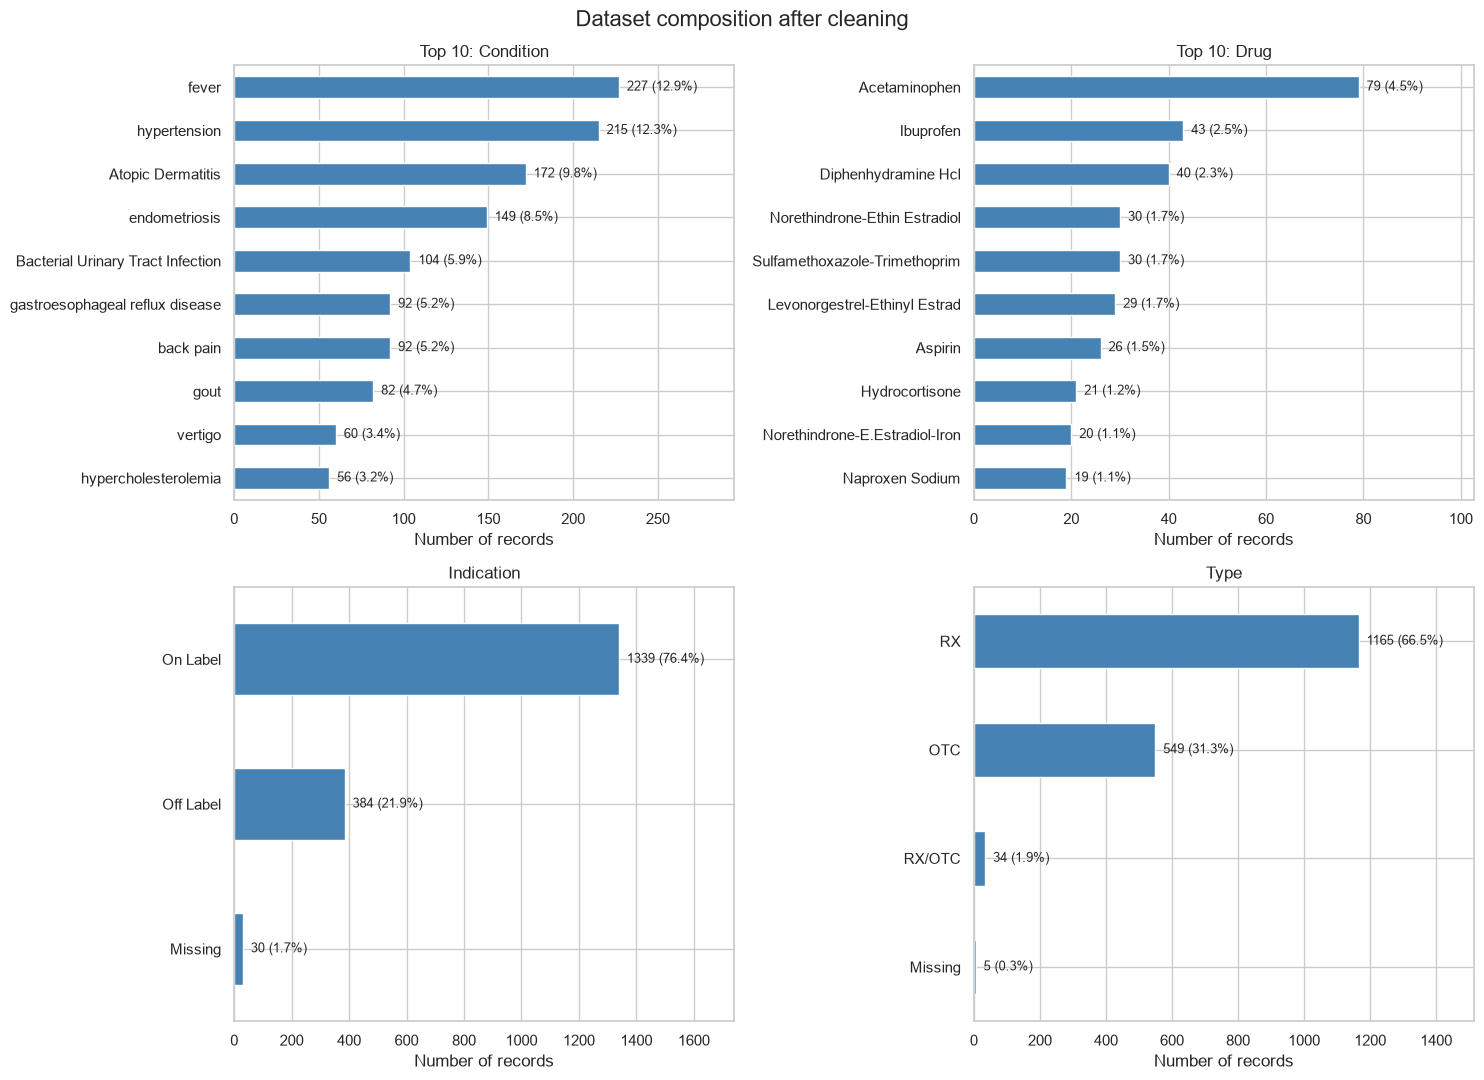

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, column in zip(
    axes.flat, ["Condition", "Drug", "Indication", "Type"]
):
    counts = df_clean[column].fillna("Missing").value_counts()
    top_counts = counts.head(10).sort_values()

    top_counts.plot.barh(ax=ax, color="steelblue")

    for position, count in enumerate(top_counts):
        percent = count / len(df_clean) * 100
        ax.text(
            count, position,
            f"  {count} ({percent:.1f}%)",
            va="center", fontsize=9
        )

    title = f"Top 10: {column}" if len(counts) > 10 else column
    ax.set_title(title)
    ax.set_xlabel("Number of records")
    ax.set_ylabel("")
    ax.set_xlim(0, top_counts.max() * 1.3)

fig.suptitle("Dataset composition after cleaning", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
plt.close("all")

## 3. Numeric distributions

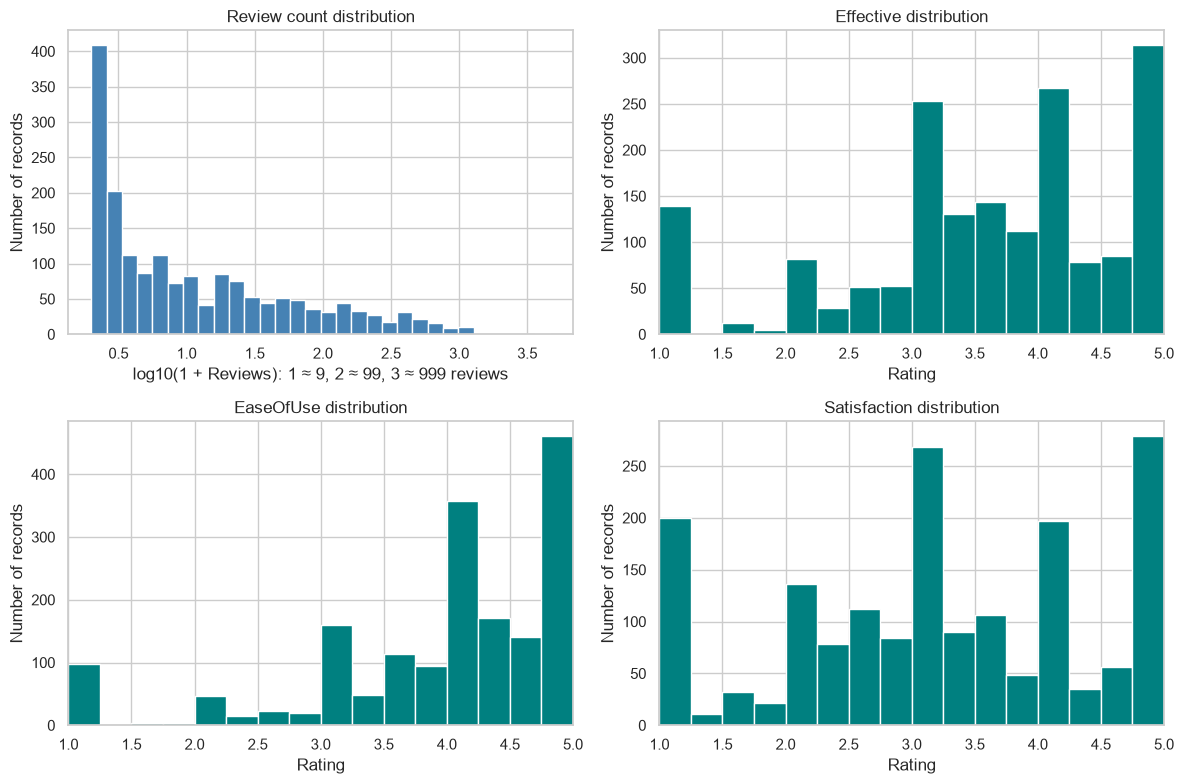

,Reviews,Effective,EaseOfUse,Satisfaction
count,1753.0,1753.00,1753.00,1753.00
mean,64.51,3.54,3.94,3.18
std,227.26,1.12,1.04,1.23
min,1.0,1.00,1.00,1.00
25%,2.0,3.00,3.50,2.34
50%,5.0,3.69,4.08,3.11
75%,30.0,4.33,4.80,4.00
max,4647.0,5.00,5.00,5.00


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Review counts often span a much wider range than ratings
reviews = df_clean["Reviews"].dropna().astype(float)
axes[0, 0].hist(
    np.log10(1 + reviews),
    bins=30,
    color="steelblue",
    edgecolor="white"
)
axes[0, 0].set_title("Review count distribution")
axes[0, 0].set_xlabel("log10(1 + Reviews): 1 ≈ 9, 2 ≈ 99, 3 ≈ 999 reviews")

# Use identical bins and axes to compare the rating distributions
rating_columns = ["Effective", "EaseOfUse", "Satisfaction"]

for ax, column in zip(axes.flat[1:], rating_columns):
    ax.hist(
        df_clean[column].dropna(),
        bins=np.linspace(1, 5, 17),
        color="teal",
        edgecolor="white"
    )
    ax.set_title(f"{column} distribution")
    ax.set_xlabel("Rating")
    ax.set_xlim(1, 5)

for ax in axes.flat:
    ax.set_ylabel("Number of records")

plt.tight_layout()
plt.show()

display(df_clean[["Reviews"] + rating_columns].describe().round(2))

In [7]:
plt.close("all")

## 4. Potential outliers
IQR flags are inspection aids, not a reason to delete records.

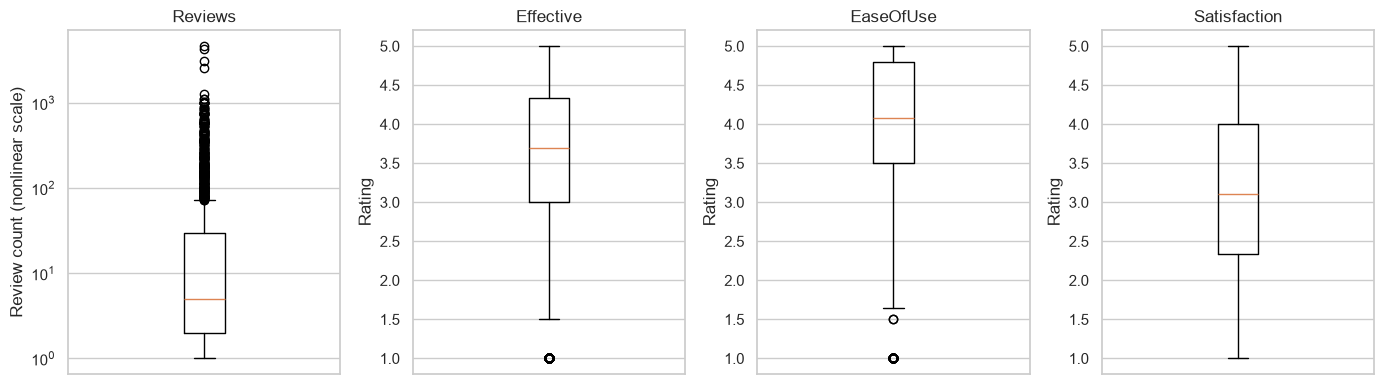

,Variable,Lower boundary,Upper boundary,Flagged records,Flagged %
0,Reviews,-40.00,72.00,281,16.03
1,Effective,1.00,6.32,139,7.93
2,EaseOfUse,1.55,6.75,99,5.65
3,Satisfaction,-0.15,6.49,0,0.00


In [8]:
numeric_columns = ["Reviews", "Effective", "EaseOfUse", "Satisfaction"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
outlier_summary = []

for ax, column in zip(axes, numeric_columns):
    values = df_clean[column].dropna().astype(float)

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (values < lower) | (values > upper)

    ax.boxplot(values, showfliers=True)
    ax.set_title(column)
    ax.set_xticks([])

    if column == "Reviews":
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel("Review count (nonlinear scale)")
    else:
        ax.set_ylabel("Rating")

    outlier_summary.append({
        "Variable": column,
        "Lower boundary": lower,
        "Upper boundary": upper,
        "Flagged records": int(flagged.sum()),
        "Flagged %": 100 * flagged.mean()
    })

plt.tight_layout()
plt.show()

display(pd.DataFrame(outlier_summary).round(2))

In [9]:
plt.close("all")

## 5. Compare the five largest condition groups

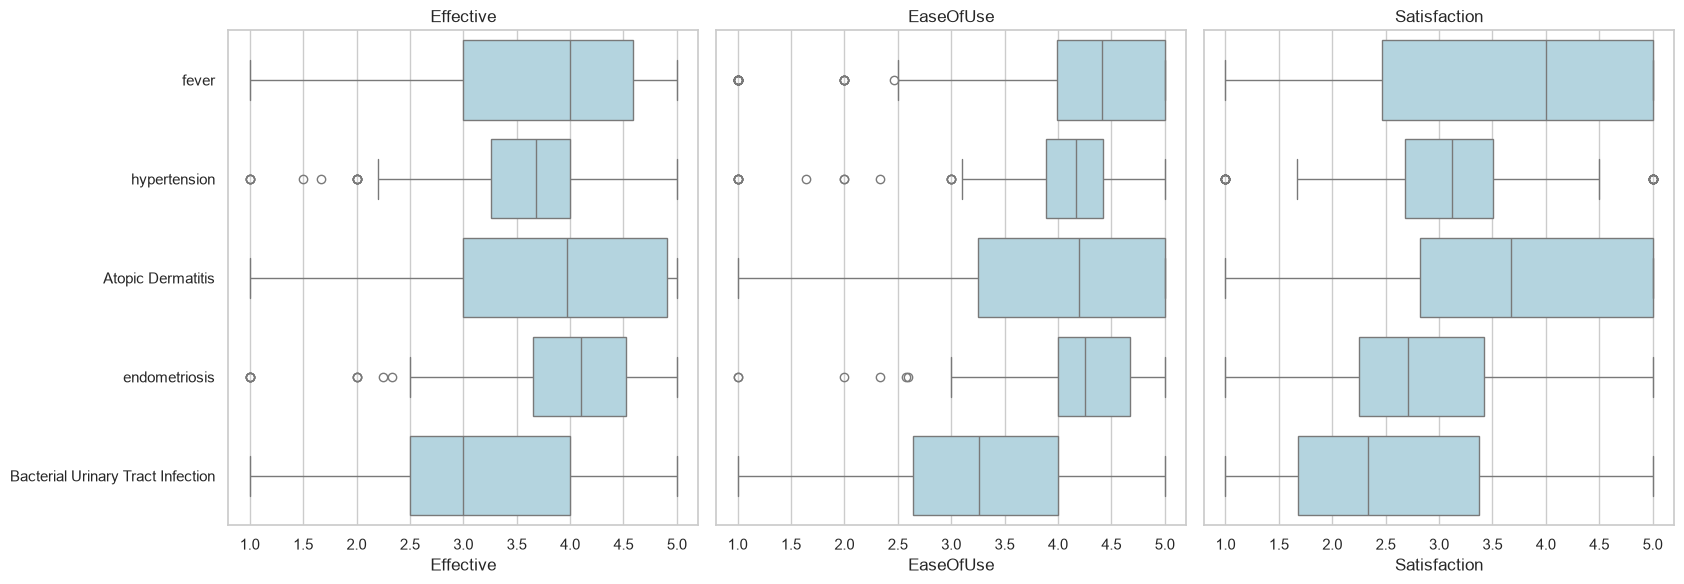

,Records,Median_reviews,Median_effective,Median_ease,Median_satisfaction
Condition,,,,,
fever,227,2.0,4.00,4.41,4.00
hypertension,215,20.0,3.68,4.17,3.12
Atopic Dermatitis,172,4.5,3.97,4.20,3.67
endometriosis,149,13.0,4.10,4.25,2.71
Bacterial Urinary Tract Infection,104,8.5,3.00,3.26,2.33


In [10]:
top_conditions = (
    df_clean["Condition"].value_counts().head(5).index
)

subset = df_clean[df_clean["Condition"].isin(top_conditions)]

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, rating in zip(
    axes, ["Effective", "EaseOfUse", "Satisfaction"]
):
    sns.boxplot(
        data=subset,
        x=rating,
        y="Condition",
        order=top_conditions,
        color="lightblue",
        ax=ax
    )
    ax.set_title(rating)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

display(
    subset.groupby("Condition")
    .agg(
        Records=("Drug", "size"),
        Median_reviews=("Reviews", "median"),
        Median_effective=("Effective", "median"),
        Median_ease=("EaseOfUse", "median"),
        Median_satisfaction=("Satisfaction", "median")
    )
    .reindex(top_conditions)
    .round(2)
)

In [11]:
plt.close("all")

## 6. Rating associations
Spearman correlation measures association, not causation.

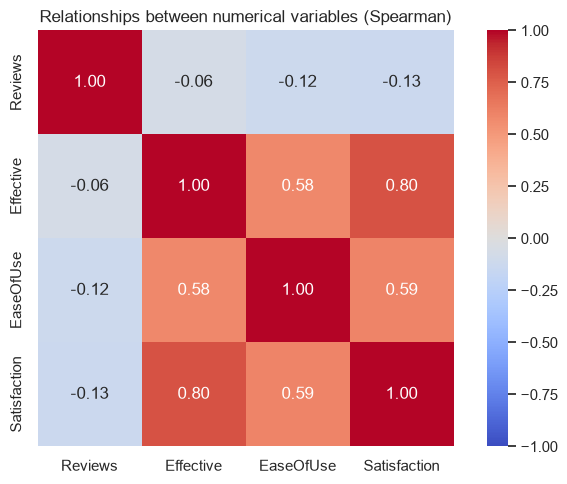

In [12]:
numeric_columns = [
    "Reviews", "Effective", "EaseOfUse", "Satisfaction"
]

correlations = df_clean[numeric_columns].corr(method="spearman")

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Relationships between numerical variables (Spearman)")
plt.tight_layout()
plt.show()

In [13]:
plt.close("all")

## 7. Coverage and imbalance


Condition


,Records,Percent
Condition,,
fever,227,12.95
hypertension,215,12.26
Atopic Dermatitis,172,9.81
endometriosis,149,8.50
Bacterial Urinary Tract Infection,104,5.93
back pain,92,5.25
gastroesophageal reflux disease,92,5.25
gout,82,4.68
vertigo,60,3.42



Indication


,Records,Percent
Indication,,
On Label,1339,76.38
Off Label,384,21.91
Missing,30,1.71



Type


,Records,Percent
Type,,
RX,1165,66.46
OTC,549,31.32
RX/OTC,34,1.94
Missing,5,0.29


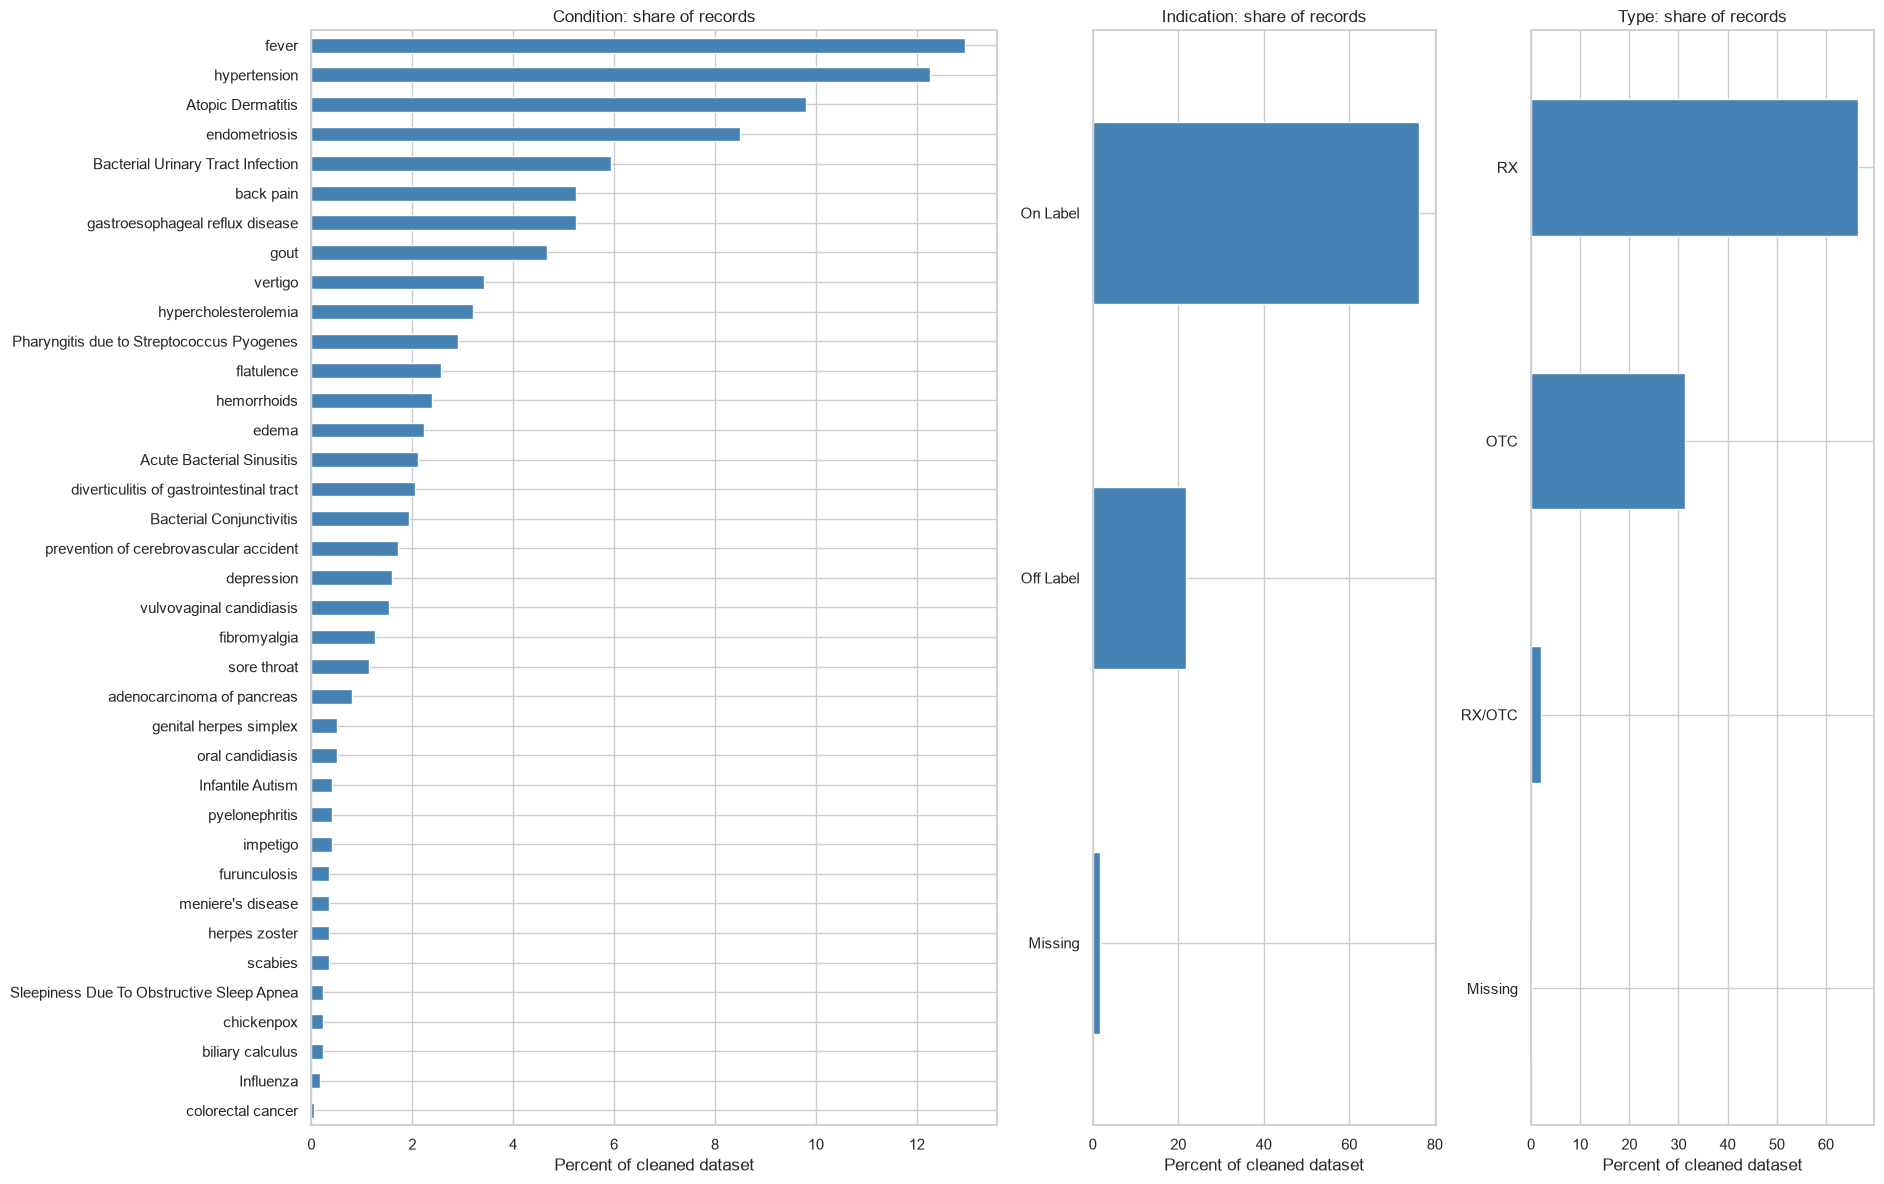

In [14]:
columns = ["Condition", "Indication", "Type"]
fig, axes = plt.subplots(
    1, 3, figsize=(19, 12),
    gridspec_kw={"width_ratios": [2, 1, 1]}
)

for ax, column in zip(axes, columns):
    counts = df_clean[column].fillna("Missing").value_counts()
    percentages = counts / len(df_clean) * 100

    percentages.sort_values().plot.barh(
        ax=ax, color="steelblue"
    )

    ax.set_title(f"{column}: share of records")
    ax.set_xlabel("Percent of cleaned dataset")
    ax.set_ylabel("")

    print(f"\n{column}")
    display(pd.DataFrame({
        "Records": counts,
        "Percent": percentages.round(2)
    }))

plt.tight_layout()
plt.show()

In [15]:
plt.close("all")

## 8. Computed summary
Use the current outputs when writing up findings.

In [16]:
summary = pd.Series({
    "Cleaned records": len(df_clean),
    "Unique drug names": df_clean["Drug"].nunique(),
    "Unique conditions": df_clean["Condition"].nunique(),
    "Median review count": df_clean["Reviews"].median(),
    "Missing indication": df_clean["Indication"].isna().sum(),
    "Missing type": df_clean["Type"].isna().sum(),
    "Effectiveness/satisfaction Spearman": correlations.loc["Effective", "Satisfaction"],
})
display(summary.to_frame("Value"))

,Value
Cleaned records,1753.000000
Unique drug names,470.000000
Unique conditions,37.000000
Median review count,5.000000
Missing indication,30.000000
Missing type,5.000000
Effectiveness/satisfaction Spearman,0.798598


## Interpretation notes
- Compare review-count skew and category imbalance in the plots above.
- Retained outliers can be legitimate observations.
- Results describe dataset records, not patient counts, prescribing frequency, or prevalence.
- Source descriptions can contain promotional content or mismatches; cleaning formatting
  does not establish factual accuracy.
- Correlation and user ratings do not establish treatment suitability.